In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/modeling_dataset_v1.csv")

df = df.drop(columns=["st_lum"])  # if not already removed

features = ["pl_rade", "pl_orbsmax", "st_teff", "st_lum_linear", "teq_recalc"]

df[features].skew()

pl_rade           1.586140
pl_orbsmax       20.007863
st_teff           9.056625
st_lum_linear    36.171729
teq_recalc        2.214998
dtype: float64

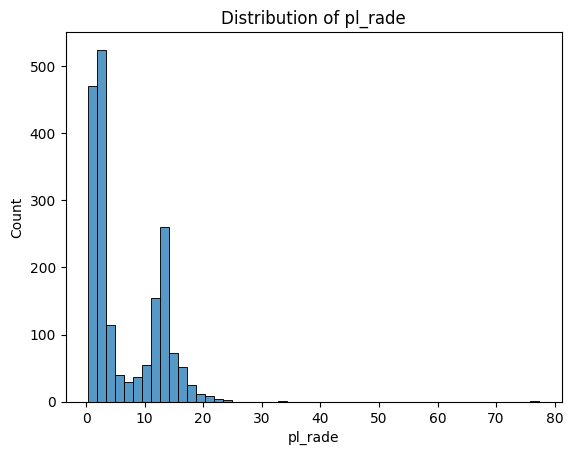

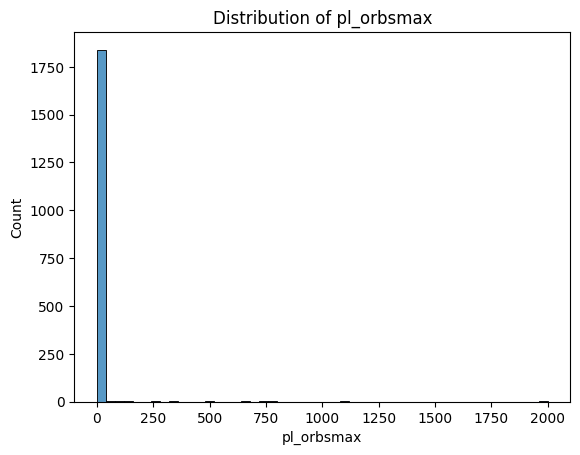

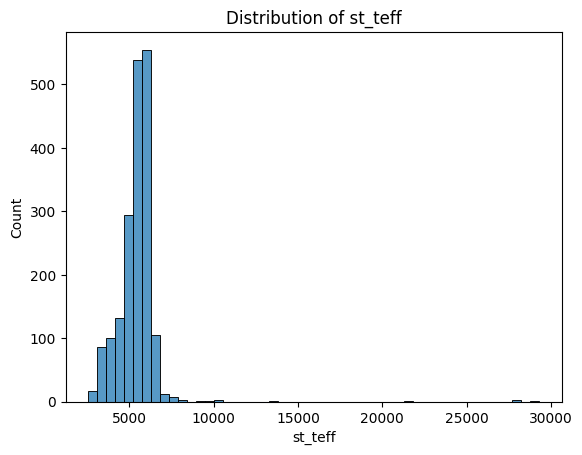

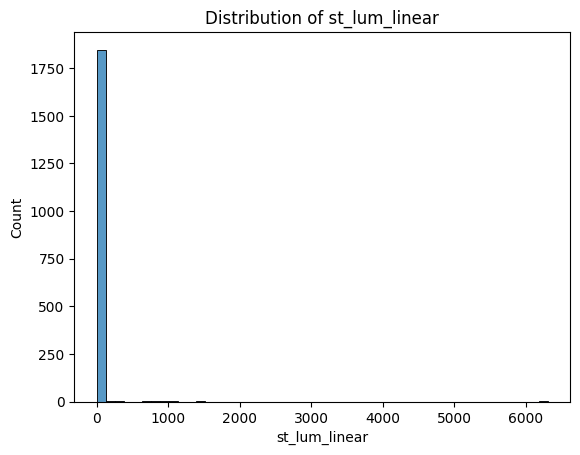

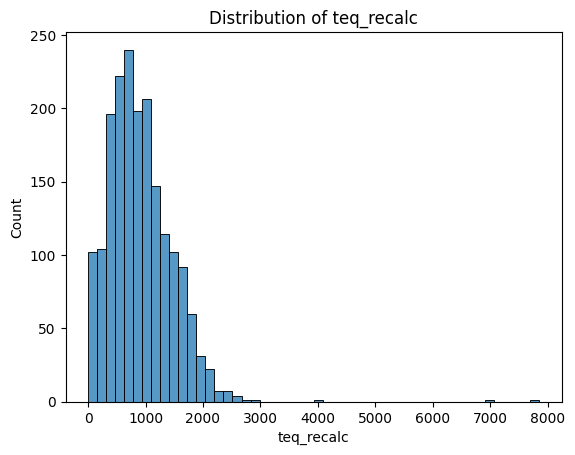

In [22]:
for col in features:
    plt.figure()
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.show()

In [23]:
df["log_pl_orbsmax"] = np.log1p(df["pl_orbsmax"])
df["log_st_lum"] = np.log1p(df["st_lum_linear"])
df["log_pl_rade"] = np.log1p(df["pl_rade"])
df["log_teq"] = np.log1p(df["teq_recalc"])
df["log_st_teff"] = np.log1p(df["st_teff"])

In [24]:
log_features = [
    "log_pl_orbsmax",
    "log_st_lum",
    "log_pl_rade",
    "log_teq",
    "log_st_teff"
]

df[log_features].skew()

log_pl_orbsmax    5.558925
log_st_lum        3.277592
log_pl_rade       0.285719
log_teq          -1.903035
log_st_teff       0.338937
dtype: float64

In [26]:
df.columns

Index(['pl_name', 'hostname', 'pl_rade', 'pl_orbsmax', 'st_teff', 'teq_recalc',
       'st_lum_linear', 'habitable', 'log_pl_orbsmax', 'log_st_lum',
       'log_pl_rade', 'log_teq', 'log_st_teff'],
      dtype='str')

In [27]:
df["stellar_flux"] = df["st_lum_linear"] / (df["pl_orbsmax"] ** 2)
df["log_stellar_flux"] = np.log1p(df["stellar_flux"])

In [28]:
df[["stellar_flux", "log_stellar_flux"]].head()

,stellar_flux,log_stellar_flux
0,950.679004,6.858228
1,137.247703,4.929047
2,521.877913,6.259348
3,2383.344727,7.776680
4,5.491944,1.870562


In [29]:
df = df.drop(columns=["pl_name", "hostname"])

In [30]:
df = df.drop(columns=[
    "pl_rade",
    "pl_orbsmax",
    "st_teff",
    "st_lum_linear",
    "teq_recalc",
    "stellar_flux"
])

In [31]:
df.columns

Index(['habitable', 'log_pl_orbsmax', 'log_st_lum', 'log_pl_rade', 'log_teq',
       'log_st_teff', 'log_stellar_flux'],
      dtype='str')

In [32]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["habitable"])
y = df["habitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nClass distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nClass distribution (Test):")
print(y_test.value_counts(normalize=True))

Train shape: (1487, 6)
Test shape: (372, 6)

Class distribution (Train):
habitable
0    0.99462
1    0.00538
Name: proportion, dtype: float64

Class distribution (Test):
habitable
0    0.994624
1    0.005376
Name: proportion, dtype: float64


In [33]:
print("Train counts:")
print(y_train.value_counts())

print("\nTest counts:")
print(y_test.value_counts())

Train counts:
habitable
0    1479
1       8
Name: count, dtype: int64

Test counts:
habitable
0    370
1      2
Name: count, dtype: int64


In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{np.int64(0): np.float64(0.5027045300878973), np.int64(1): np.float64(92.9375)}

In [35]:
class_weight_dict = {
    int(k): float(v)
    for k, v in class_weight_dict.items()
}

class_weight_dict

{0: 0.5027045300878973, 1: 92.9375}